# Cubo gelatinoso

## Introdução

O K-NN (*Nearest neighbors*) é um classificador que permite selecionar a alternativa mais provável na qual o dado se encaixa, aplicando concepções matemáticas para analisar essa probabilidade. Nesse contexto, essa estratégia passa a ser utilizada para avaliar as características de uma estrela, como distância, magnitude aparente, magnitude absoluta, *color index* e o hemisfério no qual ela é observada, e com base nelas avaliar o tipo espectral em que ela se enquadra, com base nos vizinhos mais próximos. 

Para aplicar esse classificador, será utilizado o módulo `scikit-learn`, que é especializado em realizar tarefas de aprendizado de máquina e apresenta diversos comandos que facilitam e permitem um código mais limpo e direto.

## Dados

Os dados utilizados têm origem no catálogo "HYG Database" [1] e apresenta diversas informações de aproximadamente 120 mil estrelas. Para poder lidar com um conjunto de dados tão extenso, o primeiro passo é observar os atributos e o target que serão utilizados. Nesse caso, eles são os apresentados na introdução, exceto o hemisfério que vai derivar futuramente de `dec`, que se refere à declinação da estrela. 

In [1]:
import pandas as pd

DATASET = pd.read_csv("hyg_v44.csv.gz")
print(DATASET.head())

ATRIBUTOS = [
    "mag",
    "absmag", 
    "dist", 
    "ci",
    "dec",     
]
TARGET = ["spect"]

   id  hip        hd  hr   gl   bf proper        ra        dec      dist  ...  \
0   0  NaN       NaN NaN  NaN  NaN    Sol  0.000000   0.000000    0.0000  ...   
1   1  1.0  224700.0 NaN  NaN  NaN    NaN  0.000060   1.089009  219.7802  ...   
2   2  2.0  224690.0 NaN  NaN  NaN    NaN  0.000283 -19.498840   47.9616  ...   
3   3  3.0  224699.0 NaN  NaN  NaN    NaN  0.000335  38.859279  442.4779  ...   
4   4  4.0  224707.0 NaN  NaN  NaN    NaN  0.000569 -51.893546  134.2282  ...   

   bayer  flam  con  comp  comp_primary base         lum  var  var_min  \
0    NaN   NaN  NaN     1             0  NaN    1.000000  NaN      NaN   
1    NaN   NaN  Psc     1             1  NaN    9.638290  NaN      NaN   
2    NaN   NaN  Cet     1             2  NaN    0.392283  NaN      NaN   
3    NaN   NaN  And     1             3  NaN  386.901132  NaN      NaN   
4    NaN   NaN  Phe     1             4  NaN    9.366989  NaN      NaN   

   var_max  
0      NaN  
1      NaN  
2      NaN  
3      NaN  
4  

In [2]:
len(DATASET)

119614

In [3]:
df_simples =  DATASET.dropna(subset= ATRIBUTOS + TARGET)

len(df_simples)

115357

O `df_simples` cria um dataframe com apenas os atributos e o target definidos, retirando os NaN. Além disso, ao aplicar `len` sobre ele é possível observar a quantidade todal de dados que serão trabalhados após essa retirada, que passaram a ser aproximadamente 115 mil.

O objetivo desse trabalho é classificar a luminosidade de cada estrela, como observado anteriormente esse banco de dados apresenta muitos valores ausentes. Por esse motivo, as estrelas serão filtradas pelas que possuem maior brilho, já que essas costumam ser mais estudadas e documentadas. 

Para isso, deve-se entender a relação inversamente proporcional entre a magnitude aparente e brilho. Essa proporção se origina do "ranking" criado pelo astrônomo grego Hiparco, que "alocou às estrelas mais brilhantes do céu uma magnitude m=1, às um pouco menos brilhantes do que as primeiras uma magnitude m=2, e assim por diante, até que todas as estrelas visíveis por ele tivessem valores de magnitude de 1 a 6, sendo este último valor atribuído às estrelas menos brilhantes do céu" [11]. 

Por esse motivo, foi utilizado um `sort_values` crescente no atributo `mag`, assim as primeiras apresentam menor magnitude e maior brilho.

In [4]:
brilho = df_simples.sort_values("mag", ascending = True)
print(brilho)

            id      hip        hd      hr        gl         bf  \
0            0      NaN       NaN     NaN       NaN        NaN   
32263    32263  32349.0   48915.0  2491.0   Gl 244A   9Alp CMa   
30365    30365  30438.0   45348.0  2326.0       NaN    Alp Car   
69450    69451  69673.0  124897.0  5340.0    Gl 541  16Alp Boo   
71455    71456  71683.0  128620.0  5459.0   Gl 559A    Alp1Cen   
...        ...      ...       ...     ...       ...        ...   
118139  118144      NaN       NaN     NaN   GJ 3158        NaN   
119259  119275      NaN       NaN     NaN   Gl 752B        NaN   
118545  118555      NaN       NaN     NaN  Gl 316.1        NaN   
118839  118850      NaN       NaN     NaN   GJ 3754        NaN   
118772  118783      NaN       NaN     NaN   GJ 3693        NaN   

                 proper         ra        dec     dist  ...  bayer  flam  con  \
0                   Sol   0.000000   0.000000   0.0000  ...    NaN   NaN  NaN   
32263            Sirius   6.752481 -16.716116

O enunciado da atividade pedia explicitamente mais de 150 exemplos, já esse banco apresenta ~115 mil dados. Diante dessa dissonância, julguei mais adequado limitar a quantidade de dados para 2000, pois é um valor que respeita o definido pelo professor e não é tão pesado para o computador rodar, mas que ainda representa uma boa fração do total e que eu me sinto mais confortável e confiante de utilizar, sabendo que é minha primeira vez lidando com o desempenho de modelos induzidos pelo algoritmo de 𝑘 vizinhos mais próximos.

In [5]:
df_2000 = brilho.head(2000).copy()
len(df_2000)

2000

In [6]:
df_2000["spect"].unique()

array(['G2V', 'A0m...', 'F0Ib', 'K2IIIp', 'A0Vvar', 'M1: comp', 'B8Ia',
       'F5IV-V', 'M2Ib', 'B3Vp', 'B1III', 'A7IV-V', 'B0.5IV', 'K5III',
       'B1V', 'M1Ib + B2.5V', 'K0IIIvar', 'A3V', 'A2Ia', 'B0.5III', 'K1V',
       'B7V', 'B2II', 'A2Vm', 'M4III', 'B1.5IV+...', 'B2III', 'B7III',
       'A2IV', 'B0Ia', 'B7IV', 'O9.5Ib SB', 'WC8 + O9I', 'A0p', 'F5Ib',
       'B9.5III', 'F7V comp', 'F8Ia', 'B3V SB', 'K3III+B2V', 'F1II',
       'A2V', 'K2IIb-IIIa', 'A1V', 'A0IV', 'B2IV', 'F7:Ib-IIv SB',
       'B1II/III', 'K3III', 'K0III', 'K2III', 'B2.5V', 'K0IIIb',
       'K4IIIvar', 'B0.5Iavar', 'M0IIIvar', 'M5III', 'B9p', 'A5III',
       'B8V', 'A3Vvar', 'B0IV:evar', 'A1IV', 'O5IAf', 'A8Ib', 'A0V',
       'K4Ib-II', 'F8Ib', 'K0II-IIIvar', 'O9.5II', 'F2III-IV', 'B0.2IV',
       'K2IIIb', 'B1.5III', 'B1Vn + A', 'A0', 'K2Ibvar', 'K0III...',
       'A0V SB', 'A2.5Va', 'M2II-IIIvar', 'B5Ia', 'O9.5V', 'M2III',
       'B2.5IV', 'A4V', 'B0.5V', 'B2IVne', 'B8III', 'A3IV', 'A5V...',
       'G5II', 'A0p 

Como pode ser observado acima, esse conjunto de dados apresenta a classificação extensa do espectro de emissão das estrelas, considerando além da classe principal as subdivisões, a luminosidade e sufixos específicos. Para esse projeto, ela será simplificada para a classificação principal de Harvard (OBAFGKM) que refere-se à ordem de temperatura das estrelas, sendo "O" equivalente às mais quentes (acima de 30.000 K) e "M" as de menor temperatura (abaixo de 3.700 K). Além disso, as classes mais raras também serão inclusas, apesar de provavelmente causarem uma redução na acurácia mais a frente.

In [7]:
spect_simples = pd.Series(df_2000["spect"])
def principal(espectro):
    
    return espectro[0]

classe_principal = spect_simples.apply(principal)
print(classe_principal)

0        G
32263    A
30365    F
69450    K
71455    G
        ..
26575    B
69150    M
25853    K
41179    B
1704     K
Name: spect, Length: 2000, dtype: object


In [8]:
df_2000["classe_principal"] = classe_principal

## Análise exploratória de dados e correções

### Análise e gráficos

Essa etapa é importante para observar pontos fora da curva e tendências dos dados. Por esse motivo, vamos observar a distribuição das classes do *target* (classe espectral).

In [9]:
classe_principal.describe()

count     2000
unique      10
top          K
freq       498
Name: spect, dtype: object

In [10]:
classe_principal.value_counts()

spect
K    498
B    466
A    395
G    248
F    239
M    131
O     19
C      2
W      1
S      1
Name: count, dtype: int64

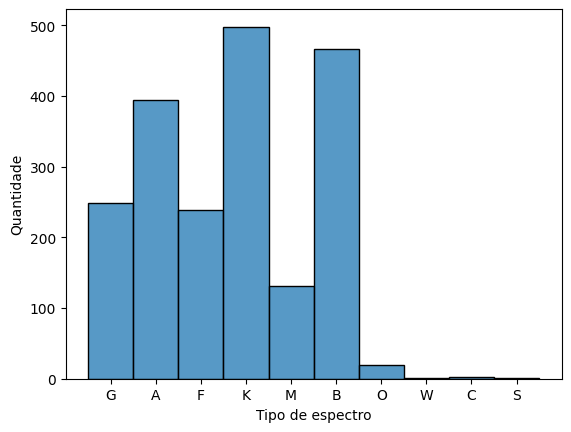

In [11]:
import seaborn as sns

espectros = sns.histplot(classe_principal, discrete = True)

espectros.set_xlabel("Tipo de espectro")
espectros.set_ylabel("Quantidade");

Como pode-se observar, surgiram alguns tipos de espectro que fogem a classificação principal de Harvard, mas que ainda serão consideradas. 

O primeiro é "W", que refere-se a um tipo extremamente raro de estrela, conhecido como "Estrela Wolf-Rayet" que são estrelas evoluidas, muito massivas (mais de 20 massas solares), e que perdem suas massas rapidamente por meio de ventos solares muito fortes, apresentando altas temperaturas (25000 e 50000 K)[2]. Já a classe "C" ou "estrelas de carbono", assim como a "W", equivale a estrelas em estágio avançado da evolução, geralmente gigantes vermelhas e com temperatura <3500K [8]. Por fim, o tipo "S" são gigantes de tipo tardio que constituem objetos de transição entre estrelas de tipo M e estrelas de carbono no ramo das gigantes assintóticas (AGB) [10].

Outro passo importante para essa análise é avaliar os atributos, para isso vamos aplicar novamente o comando `.describe()`, para avaliar pontos fora da curva ou algum erro como observado acima.

In [12]:
df_2000.describe()

,id,hip,hd,hr,ra,dec,dist,pmra,pmdec,rv,...,rarad,decrad,pmrarad,pmdecrad,flam,comp,comp_primary,lum,var_min,var_max
count,2000.000000,1995.000000,1999.000000,1999.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2.000000e+03,2.000000e+03,1251.000000,2000.00000,2000.000000,2.000000e+03,420.000000,420.000000
mean,59156.799000,59245.757393,107812.985993,4576.359680,12.119361,-2.901684,1872.580702,0.181055,-28.711395,2.215800,...,3.172841,-0.050644,8.777801e-10,-1.391968e-07,36.298161,1.00250,59172.726500,2.308847e+06,4.172733,4.070829
std,33307.495411,33324.881037,66888.695496,2597.817952,6.709532,40.210478,13100.038239,243.116038,178.077517,23.281061,...,1.756551,0.701805,1.178660e-06,8.633441e-07,27.823066,0.04995,33328.536888,1.907681e+07,1.070000,1.063658
min,0.000000,122.000000,28.000000,3.000000,0.000000,-83.667884,0.000000,-3678.190000,-3419.860000,-100.600000,...,0.000000,-1.460280,-1.783237e-05,-1.657995e-05,1.000000,1.00000,0.000000,1.520548e-01,-1.333000,-1.523000
25%,29732.250000,29803.500000,44440.000000,2284.000000,6.275419,-37.104705,47.275725,-30.370000,-38.867500,-12.000000,...,1.642901,-0.647599,-1.472379e-07,-1.884350e-07,13.000000,1.00000,29732.250000,3.794902e+01,3.734750,3.645750
50%,58834.000000,58905.000000,105707.000000,4630.000000,12.083216,-3.692296,89.166350,-2.845000,-9.840000,2.000000,...,3.163379,-0.064443,-1.379295e-08,-4.770567e-08,30.000000,1.00000,58834.000000,1.153454e+02,4.498000,4.404500
75%,88000.000000,88162.000000,164999.500000,6742.500000,18.001809,29.324177,153.198100,25.900000,7.535000,16.000000,...,4.712863,0.511803,1.255667e-07,3.653071e-08,53.000000,1.00000,88000.000000,3.614938e+02,4.943000,4.838500
max,119135.000000,118322.000000,225212.000000,9103.000000,23.998594,89.264109,100000.000000,3959.970000,1165.360000,182.000000,...,6.282817,1.557953,1.919848e-05,5.649825e-06,139.000000,2.00000,119195.000000,2.703958e+08,5.781000,5.171000


Como não apareceram todos os atributos, esse comando será aplicado individualmente em cada atributo.

In [13]:
df_2000["mag"].describe()

count    2000.000000
mean        4.301185
std         1.104964
min       -26.700000
25%         3.960000
50%         4.590000
75%         4.930000
max         5.180000
Name: mag, dtype: float64

In [14]:
df_2000["absmag"].describe()

count    2000.000000
mean       -0.532779
std         2.827345
min       -16.230000
25%        -1.545250
50%        -0.305000
75%         0.902000
max         6.895000
Name: absmag, dtype: float64

In [15]:
df_2000["dist"].describe()

count      2000.000000
mean       1872.580702
std       13100.038239
min           0.000000
25%          47.275725
50%          89.166350
75%         153.198100
max      100000.000000
Name: dist, dtype: float64

É possível observar a partir desse resultado, algo bem incomum: o desvio padrão é maior que a média. Além disso, o salto entre os valores do terceiro quartil para o valor máximo indica que apesar de existirem estrelas muito próximas, como observado no valor mínimo, as que apresentam uma distância maior puxam essas medições para um valor mais alto, resultando nessa dissonância. Nesse momento cabe fazer um histograma para uma melhor avaliação dessa situação. 

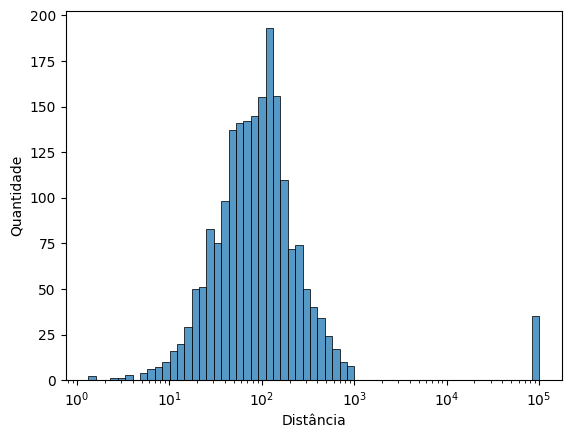

In [16]:
distancia = sns.histplot(df_2000["dist"], log_scale = True)

distancia.set_xlabel("Distância")
distancia.set_ylabel("Quantidade");

Com base nesse gráfico é possível observar que apesar de uma quantidade muito maior de estrelas apresentar distância próxima a 100, os pontos fora da curva, como $10^5$ causam essa alteração na média e no desvio padrão, como foi interpretado com o `.describe()`.

In [17]:
df_2000["ci"].describe()

count    2000.000000
mean        0.582380
std         0.611811
min        -0.269000
25%        -0.003000
50%         0.460000
75%         1.096750
max         2.800000
Name: ci, dtype: float64

In [18]:
df_2000["con"].describe()

count     1999
unique      88
top        Cen
freq        78
Name: con, dtype: object

In [19]:
df_2000["dec"].describe()

count    2000.000000
mean       -2.901684
std        40.210478
min       -83.667884
25%       -37.104705
50%        -3.692296
75%        29.324177
max        89.264109
Name: dec, dtype: float64

Inicialmente, eu planejava utilizar `con`, como atributo categórico para avaliar as estrelas. Todavia, após aplicar o `.describe()` sobre ele, percebi que havia uma cardinalidade muito alta, que eu não saberia lidar. Com isso, tive a ideia de medir a posição em que a estrela pode ser observada da Terra, assim o atributo categórico passa a ser binário (hemisfério Norte ou hemisfério Sul), o que é mais acessível para o meu entendimento no momento.

Para aplicar essa nova ideia, vamos avaliar a posição da constelação, se baseando no dado `dec`, que se refere à declinação medida em graus, variando de -90° a +90°. Como pode-se observar, uma inclinação menor que 0° equivale ao hemisfério Sul, enquanto uma maior, equivale ao Norte. Com essas informações, decidi primeiro observar os valores de declinação para em seguida criar uma função que vai realizar essa divisão.

In [20]:
df_2000["dec"].unique()

array([  0.      , -16.716116, -52.69566 , ..., -76.340964, -51.727415,
       -28.981469], shape=(2000,))

In [21]:
def posicao(declinacao):
    if declinacao < 0:
        return "Sul"
    else:
       return "Norte"

hemisferio = df_2000["dec"].apply(posicao)
print(hemisferio)
 

0        Norte
32263      Sul
30365      Sul
69450    Norte
71455      Sul
         ...  
26575    Norte
69150    Norte
25853      Sul
41179      Sul
1704       Sul
Name: dec, Length: 2000, dtype: object


In [22]:
df_2000["hemisferio"] = hemisferio

Com a divisão estabelecida e o novo dado categórico criado, o `.value_counts()` é aplicado para fazer uma caracterização e observação geral dos dados.

In [23]:
df_2000["hemisferio"].value_counts()


hemisferio
Sul      1057
Norte     943
Name: count, dtype: int64

Os outros atributos, como magnitude, magnitude absoluta e *color index* apresentaram valores mais coerentes e padronizados. Assim, não foi necessário aprofundar mais a análise deles.

### Normalização dos atributos numéricos


Agora que entendemos e organizamos os dados, é perceptível que os dados se encontram desbalanceados: enquanto a distância varia entre 1 e aproximadamente 850, a maioria dos outros dados apresenta uma variação muito menos, como a magnitude, que se encontra entre -1 e 3. Por esse motivo, é necessário que os dados sejam normalizados, a fim de que não haja um desbalanço quando for medida a distância Euclidiana entre eles, é como se fosse uma questão de equidade em vez de igualdade.

Ao pequisar acerca desse tópico, cheguei à conclusão que o método de normalização mais adequado para esses dados é o "Z-score", já que "evita problema com outliers" [7], que são valores que distoam altamente do resto do conjunto de dados. Por exemplo, o "847" apresentado na distância, enquanto a maioria dos outros valores se encontra entre 0 e 200, como observado anteriormente no gráfico.

`StandardScaler` é o módulo do `Scikit-learn` que aplica a normalização Z-score. Essa técnica realiza o seguinte cálculo: $${valor - u}/{\sigma}$$ 
Onde $u$ equivale à média do atributo e $\sigma$ equivale ao desvio padrão. Se um valor for exatamente igual à média de todos os valores da característica, ele será normalizado para 0. Se estiver abaixo da média, será um número negativo e, se estiver acima da média, será um número positivo. A magnitude desses números negativos e positivos é determinada pelo desvio padrão da característica original. Se os dados não normalizados apresentassem um desvio padrão elevado, os valores normalizados ficariam mais próximos de 0 [].

In [24]:
from sklearn.preprocessing import StandardScaler

atributos_num = [
    "dist",
    "ci",
    "absmag",
    "mag",
]
dados = df_2000[atributos_num]
scaler = StandardScaler()

print(scaler.fit(dados))
print(scaler.mean_)
print(scaler.transform(dados))

StandardScaler()
[ 1.8725807e+03  5.8238000e-01 -5.3277850e-01  4.3011850e+00]
[[ -0.14298042   0.12036142   1.90430432 -28.06330781]
 [ -0.14277907  -0.93741962   0.70287694  -5.19711236]
 [ -0.13574301  -0.68400994  -1.75870483  -4.45482098]
 ...
 [ -0.14058611   0.89530456   1.14297578   0.79553268]
 [ -0.1267001   -1.22025752  -0.32944494   0.79553268]
 [ -0.13524438   0.69257682   0.24225902   0.79553268]]


Agora que os dados já passaram por todo o processo de normalização eles se encontram em uma faixa muito menor e mais fácil de manejar, permitindo que passemos para a próxima etapa: codificar em número o atributo binário "hemisferio".

### Codificando em número o atributo categórico

Agora que o atributo categórico foi alterado para um valor binário entre "Norte" e "Sul", vamos torná-lo numérico utilizando outro módulo do `scikit-learn`, o `OneHotEncoder` que reduz esses valores a dois números associados que os representem.

In [25]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore')
X = df_2000[["hemisferio"]]

enc.fit(X)
enc.categories_
enc.transform(X).toarray()

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], shape=(2000, 2))

In [26]:
enc.categories_

[array(['Norte', 'Sul'], dtype=object)]

Outra estratégia de codificação do atributo categórico é o `OrdinalEncoder`. Nele, as variáveis são convertidas em números inteiros ordinais. Isso resulta em uma única coluna de números inteiros (de 0 a n_categorias - 1) para cada variável.

In [27]:
from sklearn.preprocessing import OrdinalEncoder

ordinal = OrdinalEncoder()
Y = df_2000[["hemisferio"]]

ordinal.fit(Y)
ordinal.categories_
ordinal.transform(Y)

array([[0.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], shape=(2000, 1))

In [28]:
ordinal.categories_

[array(['Norte', 'Sul'], dtype=object)]

Assim como no anterior, o valor 0 equivale a "Norte" e 1 equivale a "Sul". A diferença, é observada na ausência de uma coluna, sendo uma análise mais direta e equivalente.

### Unindo os atributos totais

Esses resultados podem ser interpretados ao entender a aplicação do `OneHotEncoder`, criando uma coluna binária para cada categoria de "hemisferio"(Norte e Sul). Ele avalia cada estrela e a coluna correspondente à sua categoria recebe o valor 1, enquanto a outra coluna recebe o valor 0.

Para isso, será utilizado o módulo `np.concatenate` do `numpy`, que permite unir arrays. Nesse caso, o `np.concatenate` une automaticamente as linhas, ao adicionar o "axis = 1", temos a união adequada das colunas, como podemos observar ao printar `atributos_totais`.

In [29]:
import numpy as np

total = np.concatenate ((scaler.transform(dados),enc.transform(X).toarray()), axis = 1)
print(total)
print(total.shape)

[[ -0.14298042   0.12036142   1.90430432 -28.06330781   1.
    0.        ]
 [ -0.14277907  -0.93741962   0.70287694  -5.19711236   0.
    1.        ]
 [ -0.13574301  -0.68400994  -1.75870483  -4.45482098   0.
    1.        ]
 ...
 [ -0.14058611   0.89530456   1.14297578   0.79553268   0.
    1.        ]
 [ -0.1267001   -1.22025752  -0.32944494   0.79553268   0.
    1.        ]
 [ -0.13524438   0.69257682   0.24225902   0.79553268   0.
    1.        ]]
(2000, 6)


O `print(total.shape)` permitirá observar o número de linhas e colunas de `total` e confirmar que a união entre os dois arrays funcionou. Assim, o número de linhas continua sendo 2000, como definido inicialmente pelo número de estrelas e o número de colunas passa a ser seis, sendo quatro delas referentes aos atributos numéricos e duas referentes ao atributo categórico.

Assim como com o `OneHotEncoder`, os dados organizados pelo `OrdinalEncoder` também serão unidos da mesma forma, com o objetivo de checar se o desempenho varia com apenas uma coluna de atributo, em vez de duas.

In [33]:
total_ord = np.concatenate ((scaler.transform(dados),ordinal.transform(Y)), axis = 1)
print(total_ord)
print(total_ord.shape)

[[ -0.14298042   0.12036142   1.90430432 -28.06330781   0.        ]
 [ -0.14277907  -0.93741962   0.70287694  -5.19711236   1.        ]
 [ -0.13574301  -0.68400994  -1.75870483  -4.45482098   1.        ]
 ...
 [ -0.14058611   0.89530456   1.14297578   0.79553268   1.        ]
 [ -0.1267001   -1.22025752  -0.32944494   0.79553268   1.        ]
 [ -0.13524438   0.69257682   0.24225902   0.79553268   1.        ]]
(2000, 5)


Além desse principal, será criado um caminho alternativo sem a normalização, o que permitirá uma comparação entre os dados tratados e os não normalizados.

In [34]:
total_int = np.concatenate ((dados,enc.transform(X).toarray()), axis = 1)
print(total_int)
print(total_int.shape)

[[ 0.000000e+00  6.560000e-01  4.850000e+00 -2.670000e+01  1.000000e+00
   0.000000e+00]
 [ 2.637100e+00  9.000000e-03  1.454000e+00 -1.440000e+00  0.000000e+00
   1.000000e+00]
 [ 9.478670e+01  1.640000e-01 -5.504000e+00 -6.200000e-01  0.000000e+00
   1.000000e+00]
 ...
 [ 3.135780e+01  1.130000e+00  2.698000e+00  5.180000e+00  0.000000e+00
   1.000000e+00]
 [ 2.132196e+02 -1.640000e-01 -1.464000e+00  5.180000e+00  0.000000e+00
   1.000000e+00]
 [ 1.013171e+02  1.006000e+00  1.520000e-01  5.180000e+00  0.000000e+00
   1.000000e+00]]
(2000, 6)


## Treino e Teste

No material "5.0 - Classificação binária" 10% dos dados foram utilizados para realizar o teste. Todavia, como o conjunto de dados "total" apresenta 2000 estrelas, então será utilizada uma porcentagem maior para englobar mais exemplos. 

Nesse momento temos um problema: o DataFrame que temos disponível é o `df_2000` que não está atualizado com os atributos "Norte" e "Sul", enquanto `total` que os contém é um array, não um DataFrame, o que impede realizar os treinos e testes. Além disso, o array não possui o target `classe_principal`, então além de estar com a estrutura errada, ambos estão incompletos. 

Então, o que será feito é: criar uma lista com todos os atributos, transformar o array `total` em DataFrame, nomeando as colunas seus respectivos atributos e alinhando o index dele com o de `df_2000`. Essa ação permite que os dois DataFrames sejam alinhados e que a `classe_principal` seja adicionada ao novo DataFrame e ele fique completo. Permitindo que o treino e o teste sejam realizados.

In [35]:
from sklearn.model_selection import train_test_split

colunas = ["absmag", "mag", "dist", "ci", "Norte", "Sul"]
atributos_totais = pd.DataFrame(total, index = df_2000.index, columns = colunas)
atributos_totais["espectral"] = df_2000["classe_principal"]

indices = atributos_totais.index
indices_treino, indices_teste = train_test_split(
    indices, test_size= 0.2, random_state= 10806
)

df_treino = atributos_totais.loc[indices_treino]
df_teste = atributos_totais.loc[indices_teste]

X_treino = df_treino.reindex(colunas, axis=1).values
y_treino = df_treino.reindex(["espectral"], axis=1).values.ravel()

X_teste = df_teste.reindex(colunas, axis=1).values
y_teste = df_teste.reindex(["espectral"], axis=1).values.ravel()

print(X_teste)

[[-0.14027569 -0.36193442  1.02481419  0.73216634  0.          1.        ]
 [-0.12909774 -1.27257435 -0.73416606 -0.55326507  1.          0.        ]
 [-0.12981581  0.68276742 -0.2477224   0.587329    1.          0.        ]
 ...
 [-0.13269003  0.74979836 -0.25656683  0.0803983   1.          0.        ]
 [-0.13428399 -1.10581444 -0.01069168  0.37912532  1.          0.        ]
 [-0.13701054 -0.79681812  0.38093969  0.64164301  1.          0.        ]]


In [36]:
print(X_teste.shape)

(400, 6)


Para confirmar que o código rodou corretamente, o `print` precisa apresentar um total de 400 linhas, o que equivale ao 20% definido anteriormente e as 6 colunas de atributos.

In [53]:
col_ordinal = ["absmag", "mag", "dist", "ci", "hemisferio"]
atributos_ord = pd.DataFrame(total_ord, index = df_2000.index, columns = col_ordinal)
atributos_ord["espectral"] = df_2000["classe_principal"]

indices_ord = atributos_ord.index
indices_treino_ord, indices_teste_ord = train_test_split(
    indices_ord, test_size= 0.2, random_state= 10806
)

df_treino_ord = atributos_ord.loc[indices_treino_ord]
df_teste_ord = atributos_ord.loc[indices_teste_ord]

X_treino_ord = df_treino_ord.reindex(col_ordinal, axis=1).values
y_treino_ord = df_treino_ord.reindex(["espectral"], axis=1).values.ravel()

X_teste_ord = df_teste_ord.reindex(col_ordinal, axis=1).values
y_teste_ord = df_teste_ord.reindex(["espectral"], axis=1).values.ravel()

print(X_teste_ord)

[[-0.14027569 -0.36193442  1.02481419  0.73216634  1.        ]
 [-0.12909774 -1.27257435 -0.73416606 -0.55326507  0.        ]
 [-0.12981581  0.68276742 -0.2477224   0.587329    0.        ]
 ...
 [-0.13269003  0.74979836 -0.25656683  0.0803983   0.        ]
 [-0.13428399 -1.10581444 -0.01069168  0.37912532  0.        ]
 [-0.13701054 -0.79681812  0.38093969  0.64164301  0.        ]]


In [54]:
atributos_int = pd.DataFrame(total_int, index = df_2000.index, columns = colunas)
atributos_int["espectral"] = df_2000["classe_principal"]

indices_int = atributos_int.index
indices_treino_int, indices_teste_int = train_test_split(
    indices_int, test_size= 0.2, random_state= 10806
)

df_treino_int = atributos_int.loc[indices_treino_int]
df_teste_int = atributos_int.loc[indices_teste_int]

X_treino_int = df_treino_int.reindex(colunas, axis=1).values
y_treino_int = df_treino_int.reindex(["espectral"], axis=1).values.ravel()

X_teste_int = df_teste_int.reindex(colunas, axis=1).values
y_teste_int = df_teste_int.reindex(["espectral"], axis=1).values.ravel()

print(X_teste_int)

[[ 3.542330e+01  3.610000e-01  2.364000e+00  5.110000e+00  0.000000e+00
   1.000000e+00]
 [ 1.818182e+02 -1.960000e-01 -2.608000e+00  3.690000e+00  1.000000e+00
   0.000000e+00]
 [ 1.724138e+02  1.000000e+00 -1.233000e+00  4.950000e+00  1.000000e+00
   0.000000e+00]
 ...
 [ 1.347709e+02  1.041000e+00 -1.258000e+00  4.390000e+00  1.000000e+00
   0.000000e+00]
 [ 1.138952e+02 -9.400000e-02 -5.630000e-01  4.720000e+00  1.000000e+00
   0.000000e+00]
 [ 7.818610e+01  9.500000e-02  5.440000e-01  5.010000e+00  1.000000e+00
   0.000000e+00]]


## Baseline


É importante definir uma ordem para os rótulos, principalmente devido aos oito atributos distintos que não devem ser dispostos em ordem aleatória.

In [38]:
ordem_labels = atributos_totais["espectral"].unique().tolist()

ordem_labels

['G', 'A', 'F', 'K', 'M', 'B', 'O', 'W', 'C', 'S']

Para definir o baseline, uma questão surgiu: a classe espectral "K" é muito mais frequente que todas as outras. Então, é adequado aplicar o `DummyClassifier` já que ele "sempre prevê o target mais frequente que observou durante o treino" [5]? Além disso, se ele for aplicado, como lidar com essa acurácia enganosa devido ao desbalanceamento?

Diante dessas questões, foi decidido que o mais adequado seria manter o `DummyClassifier`, tendo em vista a familiaridade maior com esse baseline utilizado em sala de aula que com um completamente novo. Também será aplicada a métrica `balanced_accuracy_score` para corrigir o desbalanço da métrica usual.

In [39]:
from sklearn.dummy import DummyClassifier

modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino, y_treino);

A matriz de confusão que será rodada a seguir é importante por confirmar a suspeita discutida acima de que o "K" será mais proeminente que as outras classes espectrais.

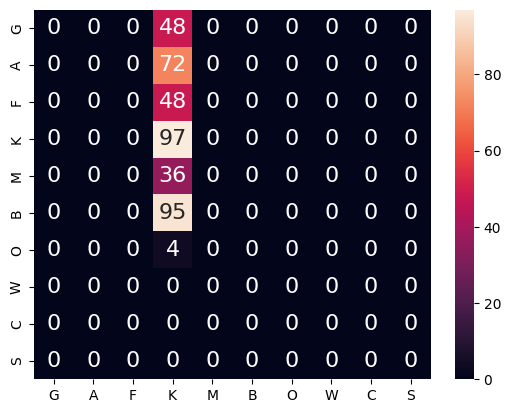

In [40]:
from sklearn.metrics import confusion_matrix

y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

O resultado foi exatamente o esperado, o "K" se manteve em destaque e a classe extremamente rara "W" não apresentou valor nenhum. Por esse motivo, é essencial aplicar a métrica.

In [41]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia = {(acuracia*100):.2f}%")

Acurácia = 24.25%


In [42]:
from sklearn.metrics import balanced_accuracy_score

acuracia = balanced_accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia balanceada = {(acuracia*100):.2f}%")

Acurácia balanceada = 14.29%


Esses resultados revelam alguns pontos fundamentais para analisar nesse projeto. O primeiro é a importância do uso da métrica balanceada, já que o `accuracy_score` apresenta uma contagem apenas dos valores que apresentaram o resultado correto, e isso em um conjunto de dados que apresenta evidentemente uma classe dominante não é tão apropriado ou certeiro. Por outro lado, o `balanced_accuracy_score` calcula a porcentagem de cada classe que foi inferida corretamente; como apenas a classe "K" de um total de sete (os espectros mais raros não foram considerados na contagem) foi medida, então é aplicado o cálculo $ \frac{100\%} {7} \approx 14\% $. 

Assim, uma acurácia tão baixa revela um ponto preocupante do baseline, já que ele não conseguiu capturar nenhum padrão além da classe majoritária. Além disso, esse baseline estabelece uma boa referência para o KNN, que deve apresentar um modelo com desempenho bem acima de 14%, revelando que o KNN realmente está aprendendo as relações entre os atributos e o target.

## $k$-vizinhos mais próximos

O $k$-vizinhos mais próximos realiza medições similares ao baseline. Contudo, o `DummyClassifier` avaliar a frequência dos valores do conjunto como um todo e escolhe a que apresenta mais repetições, enquanto o K-NN avalia apenas os mais próximos com base no valor definido e realiza a classificação com base neles.

O valor do número de vizinhos escolhido depende da quantidade de dados que possuímos, já que se refere ao número de vizinhos mais próximos que serão utilizados para comparar e calcular.

In [43]:
from sklearn.neighbors import KNeighborsClassifier

num_vizinhos = 5
KNN = KNeighborsClassifier(num_vizinhos)
KNN.fit(X_treino, y_treino);

Para poder comparar melhor esse modelo com o baseline, vamos novamente rodar a matriz de confusão.

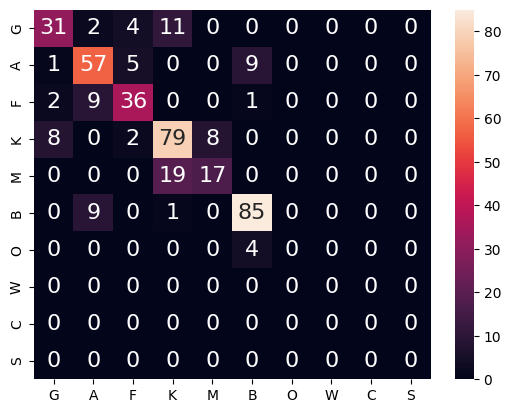

In [44]:
y_verdadeiro = y_teste
y_previsao = KNN.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

A tabela apresenta uma diagonal principal bem preenchida, apesar dos valores mais incomuns (O, W, C, S) ainda não apresentarem acertos. Também é importante observar que alguns espectros apresentam certa confusão entre seus dados, como "B" e "A" e "K" e "G", revelando certa proximidade entre essas duplas.

In [45]:
from sklearn.metrics import balanced_accuracy_score

ac_balanceada = balanced_accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia balanceada do KNN = {(ac_balanceada*100):.2f}%")

Acurácia balanceada do KNN = 62.41%


Essa acurácia apresenta um resultado bem acima da baseline, o que revela que o modelo realmente está aprendendo a comparar os atributos até chegar no target adequado.

### Combinações de hiperparâmetros

O material referência para este aqui presente sugeriu realizar pelo menos dez combinações diferentes de hiperparâmetros.

In [46]:
from itertools import product

KVIZINHOS = [3, 5, 7, 9]
P = [1,2,3]
for k_valor, p_valor in product(KVIZINHOS, P):
    modelo = KNeighborsClassifier(
        n_neighbors = k_valor, 
        p = p_valor,
    )

    modelo.fit(X_treino, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo.predict(X_teste)
    ac_balanceada = balanced_accuracy_score(y_verdadeiro, y_previsao)
    
    print(f' A acurácia balanceada do modelo, utilizando n_neighbors= {k_valor} e p= {p_valor}, é {ac_balanceada}')

 A acurácia balanceada do modelo, utilizando n_neighbors= 3 e p= 1, é 0.6687082827343273
 A acurácia balanceada do modelo, utilizando n_neighbors= 3 e p= 2, é 0.6727081879957627
 A acurácia balanceada do modelo, utilizando n_neighbors= 3 e p= 3, é 0.6627562247543256
 A acurácia balanceada do modelo, utilizando n_neighbors= 5 e p= 1, é 0.6276153226709386
 A acurácia balanceada do modelo, utilizando n_neighbors= 5 e p= 2, é 0.6241274362883154
 A acurácia balanceada do modelo, utilizando n_neighbors= 5 e p= 3, é 0.6290570713725895
 A acurácia balanceada do modelo, utilizando n_neighbors= 7 e p= 1, é 0.6394887562548985
 A acurácia balanceada do modelo, utilizando n_neighbors= 7 e p= 2, é 0.6290874307762534
 A acurácia balanceada do modelo, utilizando n_neighbors= 7 e p= 3, é 0.6211509228397454
 A acurácia balanceada do modelo, utilizando n_neighbors= 9 e p= 1, é 0.629567798361884
 A acurácia balanceada do modelo, utilizando n_neighbors= 9 e p= 2, é 0.6315519253460111
 A acurácia balanceada

Tradicionalmente, a métrica utilizada é a de "Minkowski", que apresenta os parâmentros de distância "Manhattan" e "Euclidiana". Porém, também é interessante realizar essa comparação utilizando a métrica "Chebyshev", onde a distância entre dois pontos é a maior diferença absoluta entre suas coordenadas em qualquer uma das dimensões, promovendo uma perspectiva diferente na função distância.

In [47]:
KVIZINHOS = [3, 5, 7, 9]
METRICA = ["chebyshev"]
for k_valor,m_tipo in product(KVIZINHOS, METRICA):
    modelo = KNeighborsClassifier(
        n_neighbors = k_valor, 
        metric = m_tipo,
    )

    modelo.fit(X_treino, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo.predict(X_teste)
    ac_balanceada = balanced_accuracy_score(y_verdadeiro, y_previsao)
    
    print(f' A acurácia balanceada do modelo, utilizando n_neighbors= {k_valor} e metric= {m_tipo}, é {ac_balanceada}')

 A acurácia balanceada do modelo, utilizando n_neighbors= 3 e metric= chebyshev, é 0.6170596163949392
 A acurácia balanceada do modelo, utilizando n_neighbors= 5 e metric= chebyshev, é 0.615137177135278
 A acurácia balanceada do modelo, utilizando n_neighbors= 7 e metric= chebyshev, é 0.6166709729650587
 A acurácia balanceada do modelo, utilizando n_neighbors= 9 e metric= chebyshev, é 0.6166402905890155


Com isso, a acurácia apresentou um valor mais alto com o uso dos hiperparâmetros  de vizinhos mais próximos igual a 3 e utilizando utilizando a métrica Minkowski com a distância Euclidiana (p= 2), resultando em $\approx 67\%$. Esse valor revela um grande aprendizado do algoritmo, que no `baseline` apresentou apenas $14,29\%$ de acurácia balanceada, sendo quadruplicado.

Como esses valores foram os que apresentaram maior acurácia balanceada no modelo normalizado, os mesmos serão aplicados sobre o não normalizado.

In [55]:
KVIZINHOS = [3]
P = [2]
for k_valor, p_valor in product(KVIZINHOS, P):
    modelo = KNeighborsClassifier(
        n_neighbors = k_valor, 
        p = p_valor,
    )

    modelo.fit(X_treino_ord, y_treino_ord)

    y_verdadeiro_ord = y_teste_ord
    y_previsao_ord = modelo.predict(X_teste_ord)
    ac_balanceada = balanced_accuracy_score(y_verdadeiro_ord, y_previsao_ord)
    
    print(f' A acurácia balanceada do modelo com o `OrdinalEncoder`,'
          f'utilizando n_neighbors= {k_valor} e p= {p_valor}, é {ac_balanceada}')

 A acurácia balanceada do modelo com o `OrdinalEncoder`,utilizando n_neighbors= 3 e p= 2, é 0.6727081879957627


Como esperado, a acurácia com o `OrdinalEncoder` foi exatamente a mesma utilizando `OneHotEncoder`. Isso indica que a contribuição do atributo `hemisferio` é bem pequena em relação aos atributos numéricos normalizados.

In [48]:
KVIZINHOS = [3]
P = [2]
for k_valor, p_valor in product(KVIZINHOS, P):
    modelo = KNeighborsClassifier(
        n_neighbors = k_valor, 
        p = p_valor,
    )

    modelo.fit(X_treino_int, y_treino_int)

    y_verdadeiro_int = y_teste_int
    y_previsao_int = modelo.predict(X_teste_int)
    ac_balanceada = balanced_accuracy_score(y_verdadeiro_int, y_previsao_int)
    
    print(f' A acurácia balanceada do modelo com dados não normalizados,'
        f'utilizando n_neighbors= {k_valor} e p= {p_valor}, é {ac_balanceada}')

 A acurácia balanceada do modelo com dados não normalizados,utilizando n_neighbors= 3 e p= 2, é 0.3837456614043701


Esse resultado revela exatamente o que foi discutido anteriormente: como a distância das estrelas é muito maior que os outros atributos utilizados, ela influencia as medidas do K-NN e reduz a acurácia drasticamente.

## Conclusões e principais aprendizados

Ao longo do desenvolvimento desse projeto, foi possível observar diversos aspectos fundamentais do `scikit-learn` e sua aplicação. Em primeira instância, a discrepancia entre a acurácia balanceada do baseline de apenas 14% para o K-NN de 67% revela o desenvolvimento e aprendizado do modelo com um conjunto de dados maior aplicando a análise específica com 3, 5, 7 e 9 vizinhos mais próximos. Além disso, foi possível comparar essa diferença com os dados não normalizados que apresentaram acurácia balanceada de 38%, sendo que essa redução se deu provavelmente pelos valores do atributo `dist`, que apresenta número de potência até 10^5.

Outro ponto que é importante enfatizar é o desbalanço entre as classes espectrais: enquanto a classe "K" representa a grande maioria dos dados, "S", "W", "C" e "O" não possuem ou apresentam muitos poucos representantes, o que reduz a acurácia do modelo. Além do mais, houve certa confusão entre "A-B" e "K-G", o que pode ser explicado por características próximas entre essas classes.

Por fim, foi possível aprender e desenvolver uma base essencial da biblioteca `scikit-learn`, seus módulos variados, como os classificadores de atributo categórico `OneHotEncoder` e `OrdinalEncoder` e suas possíveis futuras aplicações no contexto profissional e em outras atividades estudantis. 

## Descrição do uso de IA neste trabalho

A IA "Claude" (Anthropic) foi utilizada como apoio didático ao longo da execução do projeto, de modo socrático: apresentando questionamentos e guiando o raciocínio e com pistas conceituais, indicando onde buscar informação (na documentação do `scikit-learn` ou em materiais externos).

O uso da Inteligência Artificial se deu, majoritariamente por: explicações conceituais, debugging (sem fornecer a solução direta), auxílio na formatação das referências bibliográficas seguindo o padrão ABNT e revisão crítica dos textos em markdown.

Todo o código e todo o texto interpretativo presentes neste notebook foram escritos pela autora. A IA não redigiu conclusões, não tomou decisões metodológicas em nome da autora (como escolha de atributos, filtros ou hiperparâmetros) e não forneceu trechos de código prontos para cópia — seu papel foi orientar a compreensão e apontar problemas a serem resolvidos.

## Referências

[1] ASTRONEXUS. HYG Database. [S. l.], 2024. Disponível em: https://codeberg.org/astronexus/hyg.

[2] ASTRONOMY UNIVERSO. Estrela Wolf-Rayet. [S. l.], 2010. Disponível em: https://astronomy-universo.blogspot.com/2010/02/estrela-wolf-rayet.html.

[3] CASSAR, Daniel R. Aprendizado de máquina: k-NN e métricas. Material didático — disciplina ATP-203. Ilum Escola de Ciência, 2026.

[4] CASSAR, Daniel R. Árvore de decisão e floresta aleatória. Material didático — disciplina ATP-203. Ilum Escola de Ciência, 2026.

[5] CASSAR, Daniel R. Classificação binária. Material didático — disciplina ATP-203. Ilum Escola de Ciência, 2026.

[6] CASSAR, Daniel R. Criaturas lendárias do Reino de Lumi e onde encontrá-las. Especificação de atividade — disciplina ATP-203. Ilum Escola de Ciência, 2026.

[7] CODECADEMY. Normalization: Min-Max Normalization and Z-Score Normalization. [S. l.]. Disponível em: https://www.codecademy.com/article/min-max-zscore-normalization.

[8] HARVARD-SMITHSONIAN CENTER FOR ASTROPHYSICS. A note on the spectral atlas and spectral classification. [S. l.]. Disponível em: https://lweb.cfa.harvard.edu/~pberlind/atlas/htmls/note.html.

[9] SCIKIT-LEARN. scikit-learn: machine learning in Python. [S. l.]. Disponível em: https://scikit-learn.org/stable/.

[10] SHETYE, Shreeya et al. S stars and s-process in the Gaia era - II. Constraining the luminosity of the third dredge-up with Tc-rich S stars. Astronomy & Astrophysics, v. 650, A118, jun. 2021. Disponível em: https://www.aanda.org/articles/aa/abs/2021/06/aa40207-20/aa40207-20.html.

[11] UNIVERSIDADE FEDERAL DO RIO GRANDE DO SUL. Propriedades das estrelas. [S. l.]. Disponível em: https://www.if.ufrgs.br/oei/stars/magsys/prop_st.htm.